In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats


In [2]:
index_names = ['unit_number', 'time_cycles']
operational_settings = ['setting_1', 'setting_2', 'setting_3']

sensor_names = [f'S_{i}' for i in range(1,22)]
col_names = index_names + operational_settings + sensor_names

print(f"Column names defined. Total columns: {len(col_names)}")

Column names defined. Total columns: 26


In [15]:
train_df  = pd.read_csv(f'train_FD001.txt', sep=r'\s+', header=None, names=col_names)
test_df  = pd.read_csv(f'test_FD001.txt', sep=r'\s+', header=None, names=col_names)
rul_df  = pd.read_csv(f'RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])

pd.set_option("display.max_columns", None)
train_df

,unit_number,time_cycles,setting_1,setting_2,setting_3,S_1,S_2,S_3,S_4,S_5,S_6,S_7,S_8,S_9,S_10,S_11,S_12,S_13,S_14,S_15,S_16,S_17,S_18,S_19,S_20,S_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,21.61,551.43,2388.19,9065.52,1.3,48.07,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,21.61,550.86,2388.23,9065.11,1.3,48.04,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,21.61,550.94,2388.24,9065.90,1.3,48.09,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,21.61,550.68,2388.25,9073.72,1.3,48.39,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_number  20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   setting_1    20631 non-null  float64
 3   setting_2    20631 non-null  float64
 4   setting_3    20631 non-null  float64
 5   S_1          20631 non-null  float64
 6   S_2          20631 non-null  float64
 7   S_3          20631 non-null  float64
 8   S_4          20631 non-null  float64
 9   S_5          20631 non-null  float64
 10  S_6          20631 non-null  float64
 11  S_7          20631 non-null  float64
 12  S_8          20631 non-null  float64
 13  S_9          20631 non-null  float64
 14  S_10         20631 non-null  float64
 15  S_11         20631 non-null  float64
 16  S_12         20631 non-null  float64
 17  S_13         20631 non-null  float64
 18  S_14         20631 non-null  float64
 19  S_15

In [28]:
print(f'Nombre de valeur null : {train_df.isnull().sum().sum()}')
print(f'Nombre de valeur dupliqué : {train_df.duplicated().sum()}')

Nombre de valeur null : 0
Nombre de valeur dupliqué : 0


In [6]:
train_df.describe()

,unit_number,time_cycles,setting_1,setting_2,setting_3,S_1,S_2,S_3,S_4,S_5,S_6,S_7,S_8,S_9,S_10,S_11,S_12,S_13,S_14,S_15,S_16,S_17,S_18,S_19,S_20,S_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,2388.096652,9065.242941,1.300000e+00,47.541168,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,0.001389,0.885092,0.070985,22.082880,4.660829e-13,0.267087,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,2387.900000,9021.730000,1.300000e+00,46.850000,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,2388.050000,9053.100000,1.300000e+00,47.350000,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,2388.090000,9060.660000,1.300000e+00,47.510000,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,2388.140000,9069.420000,1.300000e+00,47.700000,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,2388.560000,9244.590000,1.300000e+00,48.530000,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [7]:
engine = train_df.groupby('unit_number')['time_cycles'].max()

# Statistics de durée de vies
nombre_de_moteur = engine.shape[0]
duree_vie_moyenne = engine.mean()
duree_vie_max = engine.max()
duree_vie_min = engine.min()
print(f'Nombre de moteur : {nombre_de_moteur}')
print(f'La durée de vie moyenne  : {duree_vie_moyenne}')
print(f'La durée de vie maximale  : {duree_vie_max}')
print(f'La durée de vie minimum  : {duree_vie_min}')


Nombre de moteur : 100
La durée de vie moyenne  : 206.31
La durée de vie maximale  : 362
La durée de vie minimum  : 128


Il y a 100 moteur différents avec des temps de cylces varié. On en conclu qu'il n'y a pas une durée standard de vie pour les moteurs


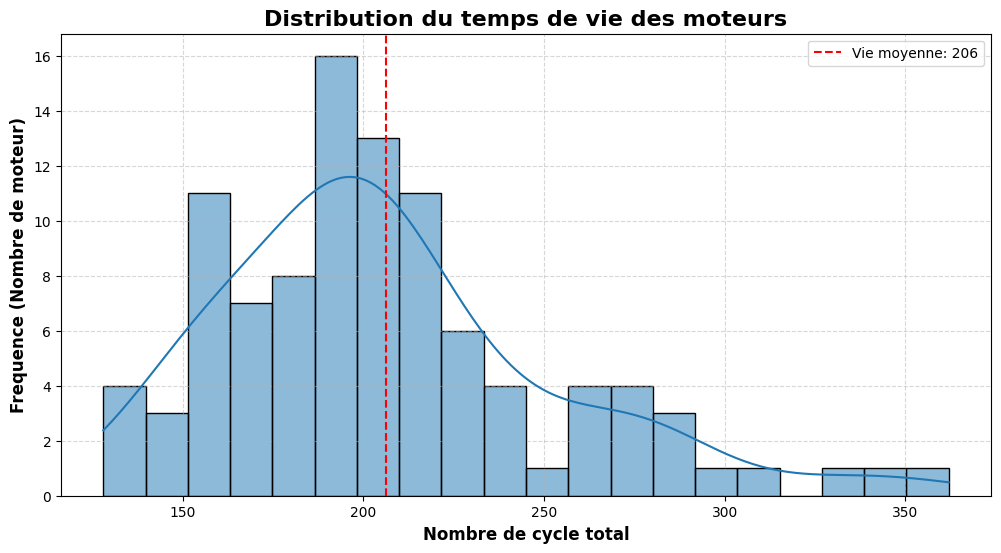

In [8]:
plt.figure(figsize=(12, 6))
sns.histplot(engine, kde=True, color='#1f77b4', bins=20)
plt.title('Distribution du temps de vie des moteurs', fontweight='bold', size=16)
plt.xlabel('Nombre de cycle total', fontweight='bold', size=12)
plt.ylabel('Frequence (Nombre de moteur)', fontweight='bold', size=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(engine.mean(), color='r', linestyle='--', label=f'Vie moyenne: {int(engine.mean())}')
plt.legend()
plt.show()

# **choix des capteurs**

## **Étape 1** : exploration et ratio pente/bruit

Avant de choisir quels capteurs utiliser pour le modèle, il faut identifier lesquels apportent une vraie information sur la dégradation du moteur, et lesquels sont plats ou trop bruités.

On commence par une exploration visuelle (graphiques des 21 capteurs pour un moteur), puis on calcule un ratio pente/bruit pour chaque capteur, moyenné sur les 100 moteurs, afin d'obtenir un score objectif et comparable.



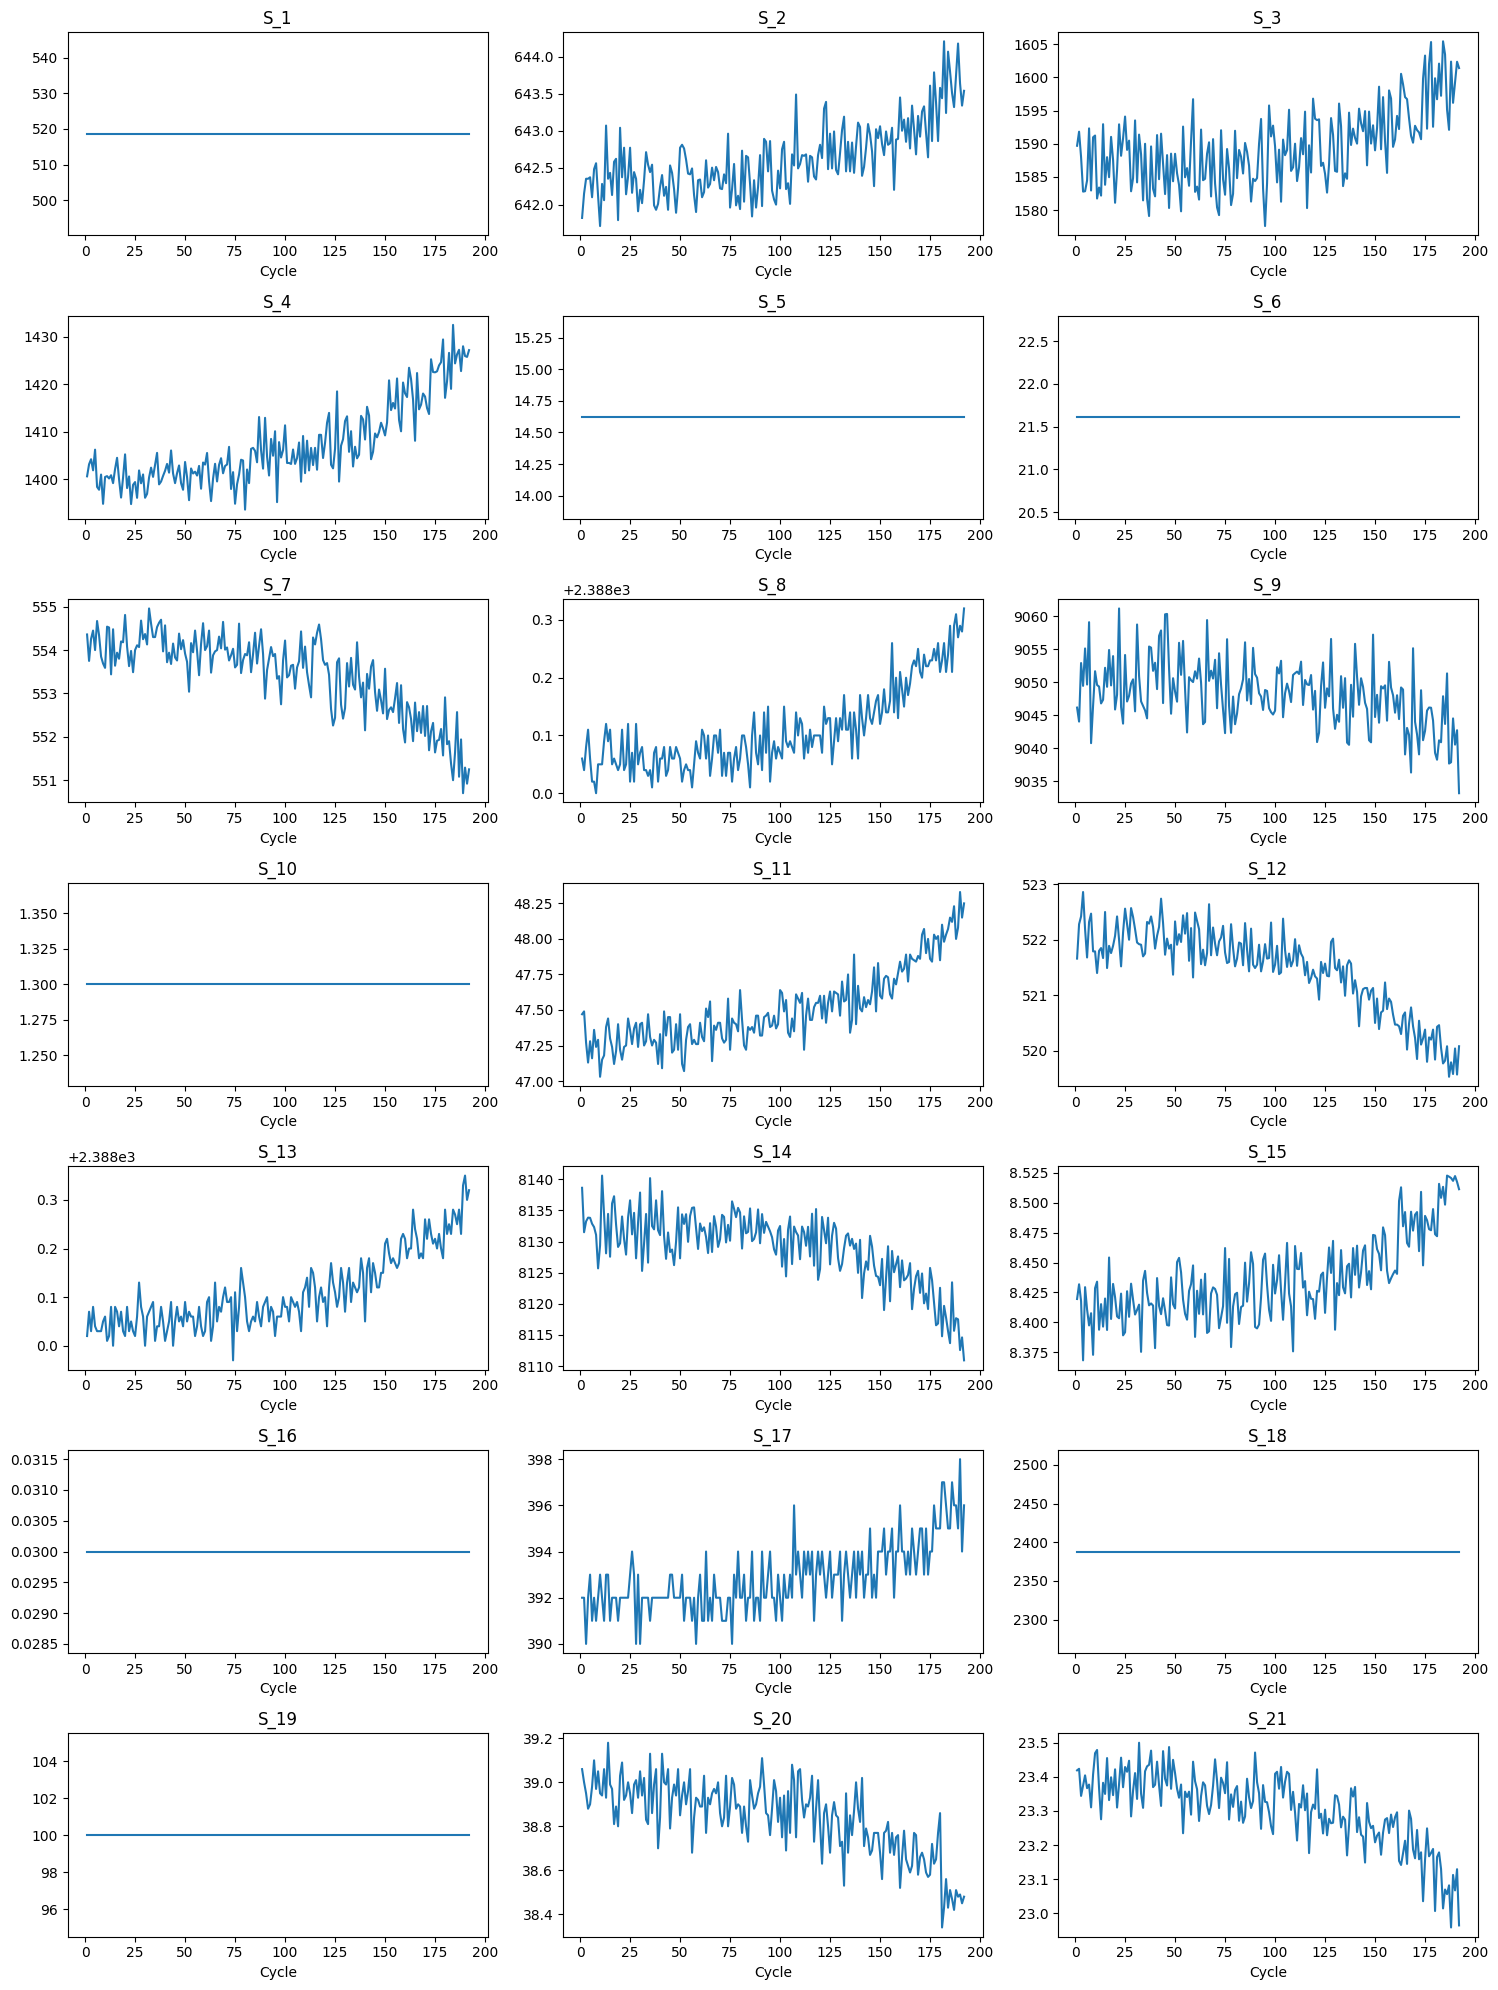

In [9]:
fig, axes = plt.subplots(7, 3, figsize=(15, 20))
axes = axes.flatten()

moteur1 = train_df[train_df['unit_number'] == 1]

for i, sensor in enumerate(sensor_names):
    axes[i].plot(moteur1['time_cycles'], moteur1[sensor])
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Cycle')

plt.tight_layout()
plt.show()

On remarque par ces visualisations que tous les capteurs n'apportent pas une information les capteurs (S_19, S_18, S_16, S_10, S_8, S_9, S_6, S_5,et S_1), ils seront assez naturellement retiré des données à analyser. Par ailleurs une vérification statistique s'impose  

In [10]:
moteur1[sensor_names].std().sort_values()

,0
S_19,0.000000e+00
S_18,0.000000e+00
S_16,1.739259e-17
S_10,4.452502e-15
S_6,3.918202e-14
S_5,6.589703e-14
S_1,1.367809e-12
S_15,3.412461e-02
S_8,7.091352e-02
S_13,7.696013e-02


Le cacul de l'écart-type le confirme, les capteurs `S_19, S_18, S_16, S_10, S_6, S_5, S_1`, n'apportent aucune information d'autant plus que leurs écart-types sont presque égles à 0. <br>
Les capteurs `S_15 et S_2` bougent mais très peu, ils sont à surveiller mais ne sont pas les plus importants ici. <br>
Après une analyse rigoureuse des visualisations des capteurs restants pour déterminer lesquelles ont une tendance suffisamment claire pour avoir un impact sur la dégradation du moteur, Une question née, on doit désormais savoir si le rapport **signale/bruit** est plus informatif que la **tendance** sur l'impact du capte sur la dégradation du moteur

In [11]:
resultats = {}

for sensor in sensor_names:
    pente, _, _, _, _ = stats.linregress(moteur1['time_cycles'], moteur1[sensor])
    bruit = moteur1[sensor].std()
    if bruit > 0:
        ratio = abs(pente) / bruit
    else:
        ratio = 0
    resultats[sensor] = ratio

ratios = pd.Series(resultats).sort_values(ascending=False)
ratios

,0
S_11,0.015153
S_12,0.015091
S_13,0.014985
S_4,0.014830
S_8,0.014495
S_7,0.014370
S_21,0.013737
S_20,0.013134
S_15,0.013025
S_14,0.012833


In [40]:
valid_capteur = ratios[ratios > 0].index.to_list()
valid_capteur

['S_11',
 'S_12',
 'S_13',
 'S_4',
 'S_8',
 'S_7',
 'S_21',
 'S_20',
 'S_15',
 'S_14',
 'S_2',
 'S_17',
 'S_3',
 'S_9']


* pente = à quel point la valeur change en moyenne à chaque cycle (la tendance)
* bruit = l'écart-type (la dispersion autour de cette tendance)
* ratio = plus il est élevé, plus le signal de dégradation est clair par rapport au bruit — donc plus le capteur est utile

Le ratio pente/bruit nous permet de voir à quel point le signal de dégradation d'un capteur est clair par rapport à son bruit, indépendamment de sa vitesse de dégradation.

L'analyse des résultats confirme ce qui a été observé visuellement : les capteurs qui n'apportent aucune information restent les mêmes (S_1, S_5, S_6, S_10, S_16, S_18, S_19 — ratio nul).

Pour les 14 capteurs restants, le ratio est assez homogène (entre 0.008 et 0.015) : aucun ne se distingue clairement des autres en termes de clarté du signal de dégradation. Ce calcul a été fait sur un seul moteur (unit 1) — il faudra vérifier si ce classement reste stable sur l'ensemble des 100 moteurs avant de tirer une conclusion définitive.

In [12]:
resultats_tous_moteurs = []

for unit in train_df['unit_number'].unique() :
  moteur = train_df[train_df['unit_number'] == unit]
  ratio_moteur = {}

  for sensor in sensor_names :
    pente, _, _, _, _= stats.linregress(moteur['time_cycles'], moteur[sensor])
    bruit = moteur[sensor].std()

    if bruit > 0 :
      ratio = abs(pente)/bruit

    else :
      ratio = 0

    ratio_moteur[sensor] = ratio

  resultats_tous_moteurs.append(ratio_moteur)

df_ratios = pd.DataFrame(resultats_tous_moteurs)
df_mean = df_ratios.mean().sort_values(ascending = False)

df_mean

,0
S_11,0.014186
S_12,0.013831
S_4,0.013685
S_7,0.013318
S_15,0.012674
S_21,0.012533
S_20,0.012491
S_13,0.012108
S_8,0.012048
S_14,0.011921


En conclusion, la sélection des 7 capteurs à exclure (capteurs plats) reste stable. Bien que la moyenne des ratios du capteur S_6 sur les 100 moteurs montre qu'il n'est plus totalement plat, son changement est minime, presque négligeable — on le garde donc dans la catégorie des capteurs exclus.

Les écarts entre les ratios des 14 autres capteurs restent assez faibles, on ne constate toujours aucune hiérarchie évidente parmi eux.

## **Étape 2** : validation statistique avec Mann-Kendall

Le ratio pente/bruit donne une intuition utile, mais ce n'est pas un test statistique reconnu, il ne permet pas d'affirmer avec certitude qu'une tendance est significative.

Pour valider rigoureusement nos résultats, on applique le test de Mann-Kendall sur chaque capteur. Ce test confirme si une tendance monotone existe réellement dans la série, et donne en plus sa direction (croissante ou décroissante).

In [17]:
import pymannkendall as mk
data = {}

for sensor in sensor_names:
    resultat = mk.original_test(moteur1[sensor])
    data[sensor] = [resultat.trend, resultat.p]

trend_df = pd.DataFrame(data).T.rename(columns={0 : 'Trend',1 : 'P.value'})
trend_df.sort_values(ascending=False, by = 'P.value')

,Trend,P.value
S_1,no trend,1.0
S_5,no trend,1.0
S_6,no trend,1.0
S_19,no trend,1.0
S_18,no trend,1.0
S_10,no trend,1.0
S_16,no trend,1.0
S_9,decreasing,0.0
S_3,increasing,0.0
S_14,decreasing,0.0


## **Conclusion**

Les deux méthodes convergent parfaitement : les mêmes 7 capteurs (S_1, S_5, S_6, S_10, S_16, S_18, S_19) sont identifiés comme plats par les deux approches, et les 14 autres capteurs montrent tous une tendance significative.

Cette convergence entre une mesure empirique (ratio pente/bruit) et un test statistique reconnu (Mann-Kendall) renforce la fiabilité de notre sélection de capteurs pour la suite du projet.

## Analyse multivarié des capteurs

L'objectif de cette étape est de trouver des relations entre les capteurs, ce qui pourrait laisser suggérer des patterns intéressants

### Analyse de la corrélation

On considèrera deux variables fortement corrélées si : $coor(var1, var2) \leq 0.8$

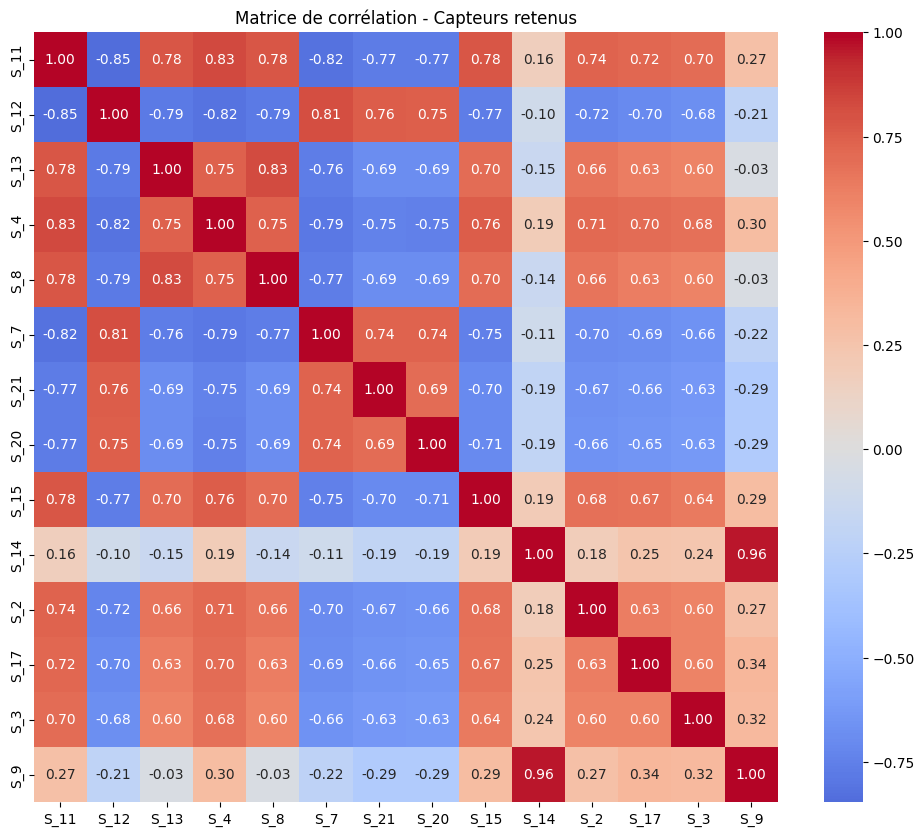

In [44]:
# Matrice de correlation entre les capteur

corr_matrix = train_df[valid_capteur].corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corrélation - Capteurs retenus")
plt.show()

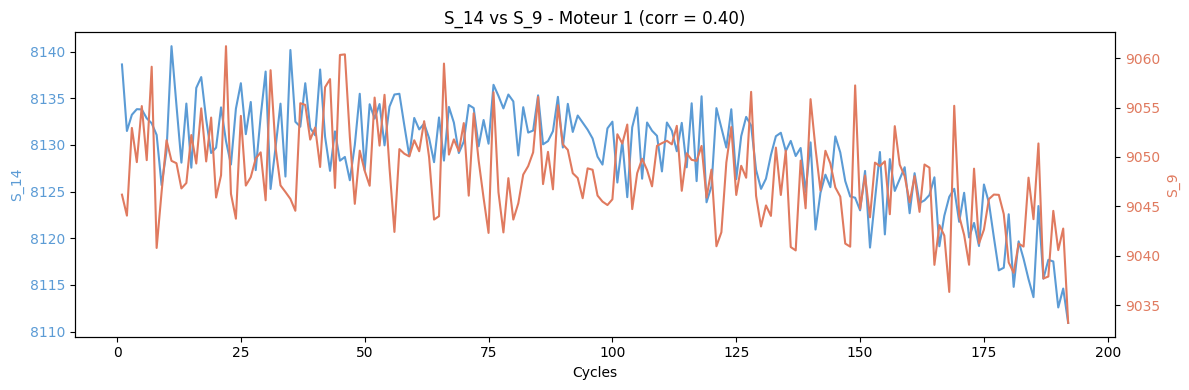

<Figure size 640x480 with 0 Axes>

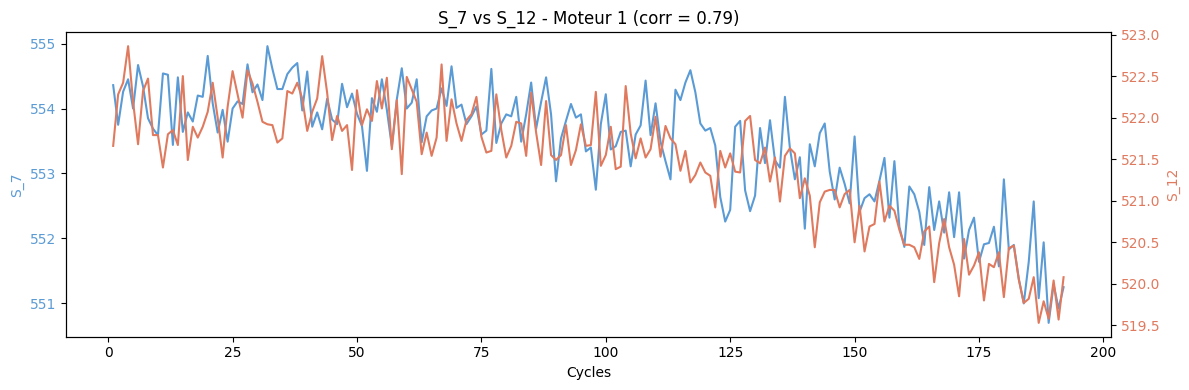

<Figure size 640x480 with 0 Axes>

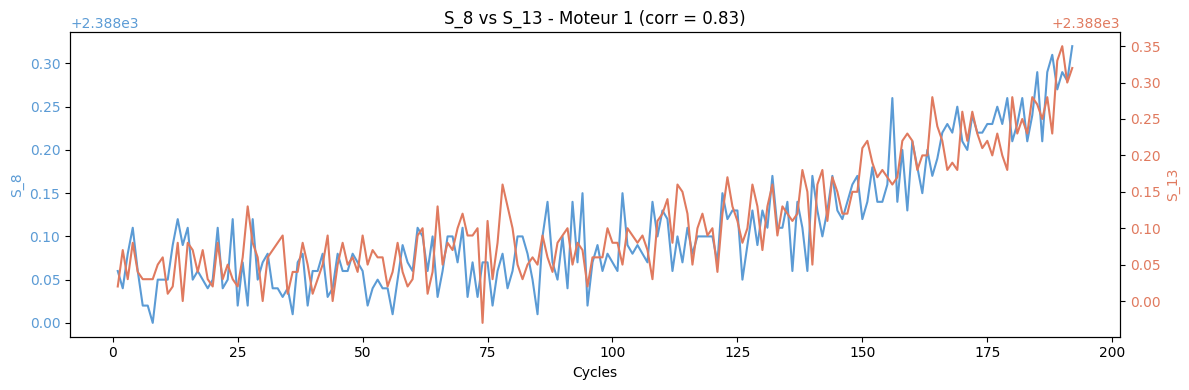

<Figure size 640x480 with 0 Axes>

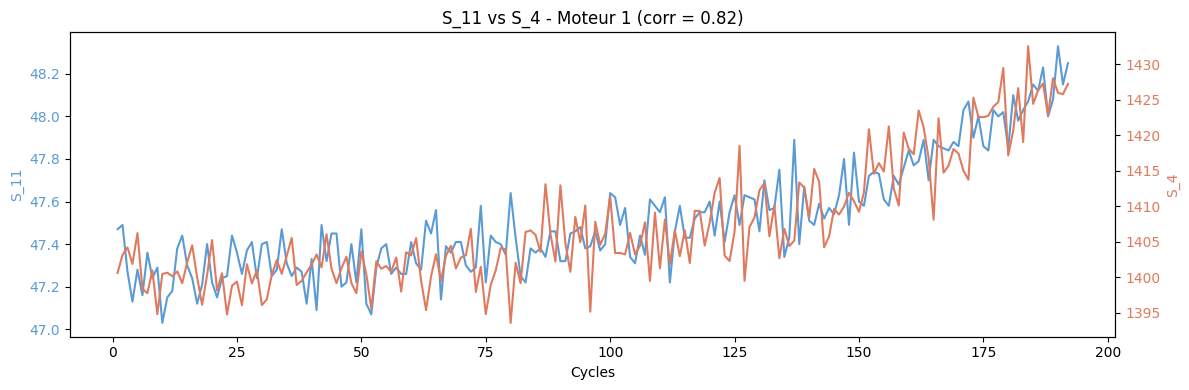

<Figure size 640x480 with 0 Axes>

In [61]:
high_corralated_sensor = [('S_14','S_9'),('S_7','S_12'),('S_8','S_13'),('S_11','S_4')]
for sensor in high_corralated_sensor:
  moteur_test = train_df[train_df['unit_number'] == 1]
  corr_val = moteur_test[sensor[0]].corr(moteur_test[sensor[1]])

  fig, ax1 = plt.subplots(figsize=(12, 4))

  ax1.plot(moteur_test['time_cycles'], moteur_test[sensor[0]], color='#5b9bd5', label=sensor[0])
  ax1.set_xlabel('Cycles')
  ax1.set_ylabel(sensor[0], color='#5b9bd5')
  ax1.tick_params(axis='y', labelcolor='#5b9bd5')

  ax2 = ax1.twinx()
  ax2.plot(moteur_test['time_cycles'], moteur_test[sensor[1]], color='#e07a5f', label=sensor[1])
  ax2.set_ylabel(sensor[1], color='#e07a5f')
  ax2.tick_params(axis='y', labelcolor='#e07a5f')

  plt.title(f'{sensor[0]} vs {sensor[1]} - Moteur 1 (corr = {corr_val:.2f})')
  fig.tight_layout()
  plt.show()
  plt.subplots_adjust(bottom=0.3)

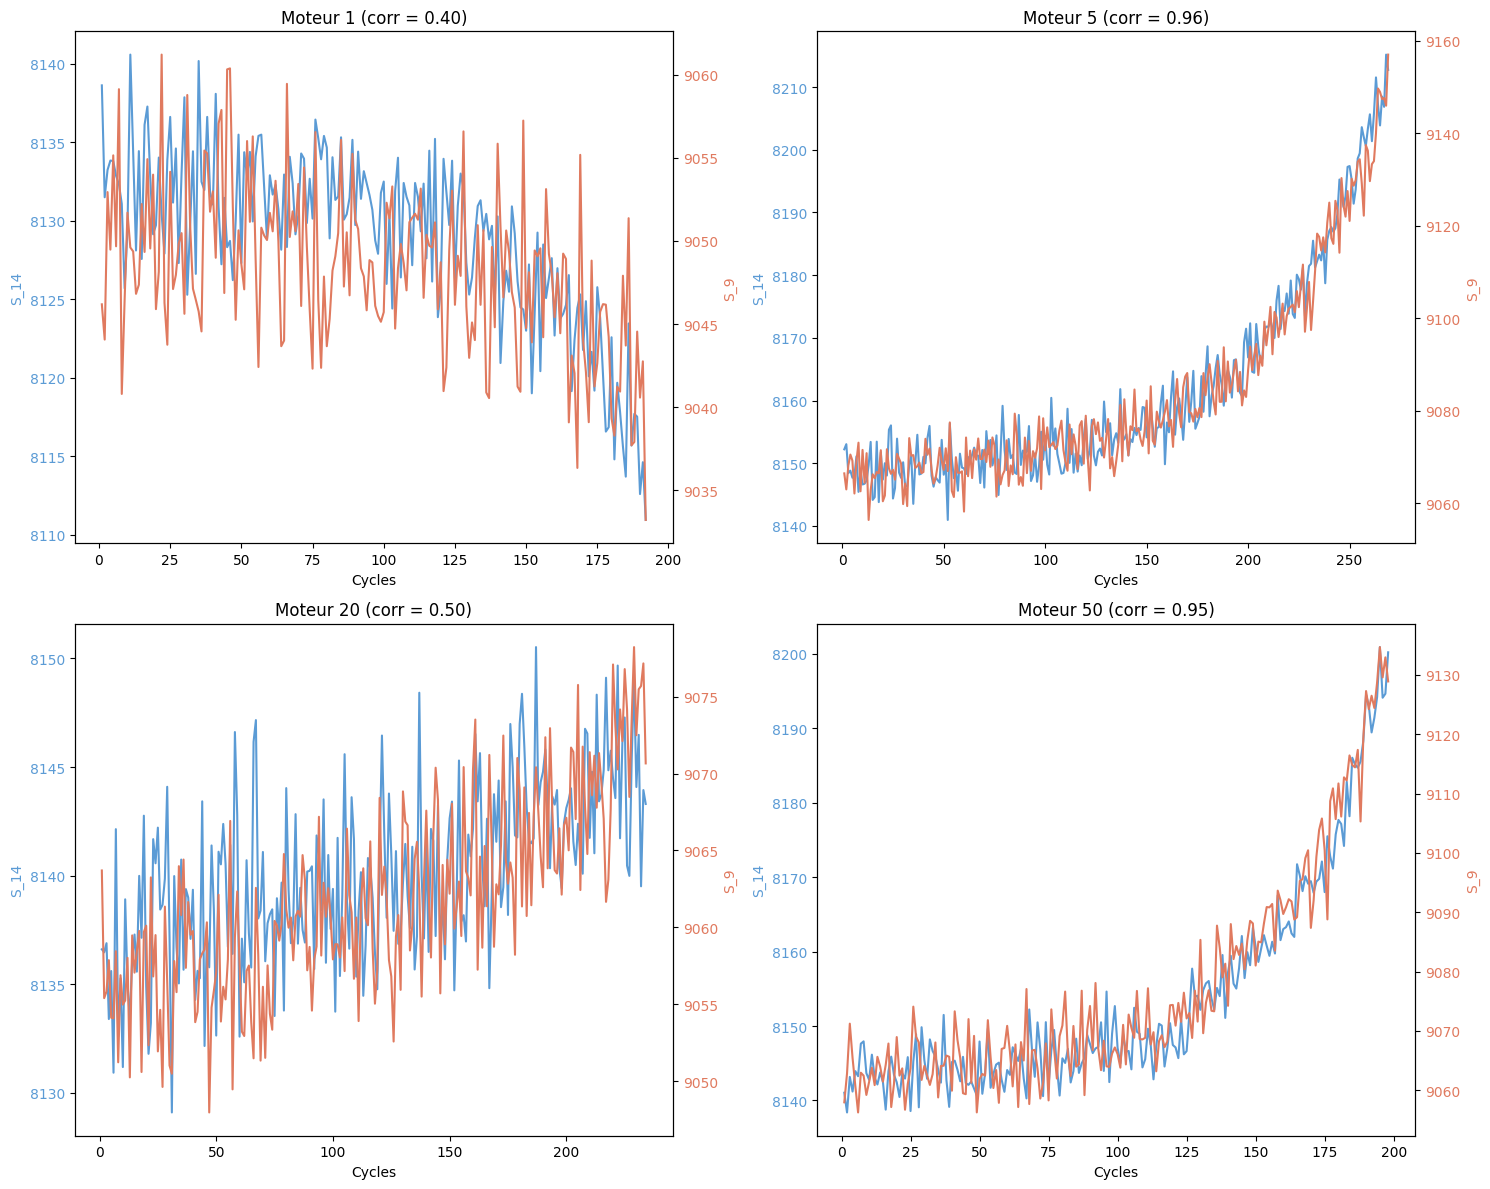

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()
axes.set_title('Analyse de corrélation des capteurs ')

unites_test = [1, 5, 20, 50]

for idx, unit in enumerate(unites_test):
    moteur_test = train_df[train_df['unit_number'] == unit]
    corr_val = moteur_test['S_14'].corr(moteur_test['S_9'])

    ax1 = axes[idx]
    ax1.plot(moteur_test['time_cycles'], moteur_test['S_14'], color='#5b9bd5', label='S_14')
    ax1.set_xlabel('Cycles')
    ax1.set_ylabel('S_14', color='#5b9bd5')
    ax1.tick_params(axis='y', labelcolor='#5b9bd5')

    ax2 = ax1.twinx()
    ax2.plot(moteur_test['time_cycles'], moteur_test['S_9'], color='#e07a5f', label='S_9')
    ax2.set_ylabel('S_9', color='#e07a5f')
    ax2.tick_params(axis='y', labelcolor='#e07a5f')

    ax1.set_title(f'Moteur {unit} (corr = {corr_val:.2f})')

fig.tight_layout()
plt.show()

## Conclusion

L'analyse de corrélation montre que les capteurs capteurs `(S_14,S_9), (S_11,S_4), (S_8, S_13) et (S_12, S_7)` ont une correlation très forte.

L'analyse visuelle sur le moteur 1 a révélé une incohérence : alors que la corrélation globale S_14/S_9 atteint 0.96, elle ne valait que 0.43 sur ce moteur précis. En élargissant à d'autres moteurs (test sur 4 moteurs au total), les résultats sont mitigés : deux moteurs montrent une corrélation supérieure à 0.95 (cohérente avec la valeur globale), tandis que deux autres (moteurs 1 et 20) tombent à 0.43 et 0.50. La relation entre ces deux capteurs semble donc varier selon le moteur plutôt que d'être uniformément forte, un point qui mériterait d'être creusé si la colinéarité entre ces deux capteurs est utilisée pour les éliminer ou les transformer dans la modélisation